# Exercise: Radioactive decay source


*   Generate 1k events distributed according to a falling exponential with
*   Tau decay constant = 1.5 ns
* X range = [0, 4] ns
* N bins = 30
* Draw the histogram of the generated events
* Draw the PDF used to generate the events
* Define the fitting function
* Define the distance between the histo and the function (Chi2)
* What is the error in each bin?
* Find the best parameter(s) that describe the data
* Perform a parameter scan and minimize the Chi2
* Compare with the result from optimize.curve_fit

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [78]:
# define constants
TAU = 1.5e-9
NBINS = 30
dim = 1000

exp = np.random.exponential(TAU, 1000)

In [79]:
x = np.linspace(0,4e-9,dim)
y = np.zeros(dim)
for i in range(dim):
  y[i] = (300)*np.exp(-x[i]/TAU)




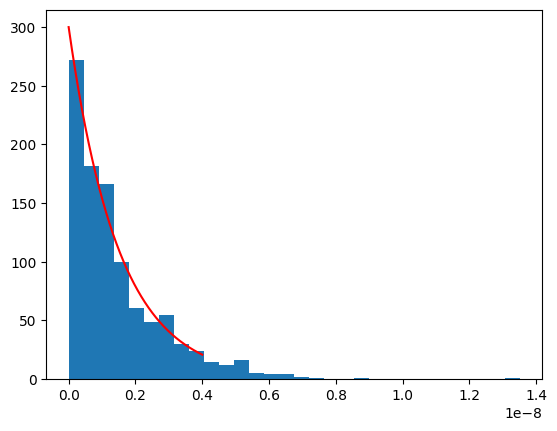

In [86]:
plt.plot(x,y,'r-')
hist = plt.hist(exp,NBINS)
plt.show()

In [87]:
len(y)

1000

In [118]:
# Funzione per il mio fit
def Esponenziale(x, A, tau):
    y = A*np.exp(-x/tau)
    return y

In [123]:
bin_counts = hist[0]
bin_edges = hist[1]

half_bin = (bin_edges[2] - bin_edges[1])/2
bin_centers= np.zeros(NBINS)
for i in range(NBINS):
  bin_centers[i] = bin_edges[i] + half_bin


def distanza_fit(y_dati, bin_centers):
  return 1/len(y_dati)*np.sum((y_dati-Esponenziale(bin_centers,314, TAU))**2)

print(distanza_fit(bin_counts,bin_centers))

48.981087251683746


In [121]:
parameters, covariance = curve_fit(Esponenziale, bin_centers, bin_counts, [300, 1.5e-9])
print(parameters)

[3.14646380e+02 1.43188068e-09]
